# Model Training & Evaluation
**Crop Classification System**


## Setup & Load Processed Data

In [7]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, f1_score,silhouette_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)

np.random.seed(42)

df = pd.read_csv('../data/processed_dataset.csv')
with open('../models/feature_cols.pkl','rb') as f:   feature_cols = pickle.load(f)
with open('../models/label_encoder_crop.pkl','rb') as f: le_crop = pickle.load(f)

X = df[feature_cols].values.astype(float)
y = df['Crop_encoded'].values.astype(int)
print(f"X shape: {X.shape} | Classes: {list(le_crop.classes_)}")

X shape: (42733, 23) | Classes: ['Cotton', 'Groundnut', 'Maize', 'Pearl Millet', 'Rice', 'Sorghum', 'Sugarcane', 'Wheat']


## PCA

In [20]:
pca = PCA(n_components=0.8, random_state=42)
X_pca = pca.fit_transform(X)

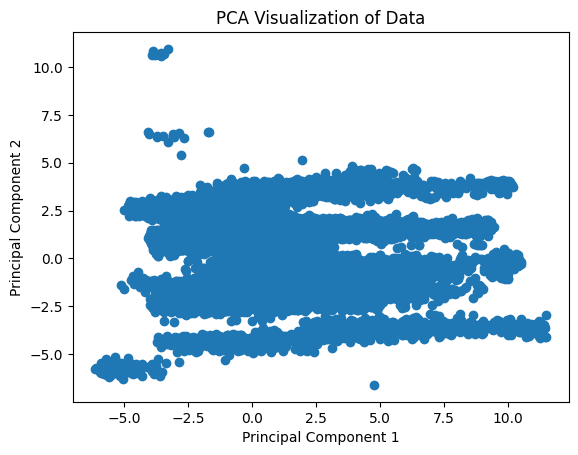

In [21]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Data")
plt.show()

In [22]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.28603265 0.15294016 0.1044043  0.06036522 0.04729843 0.04403092
 0.04353679 0.04347752 0.04306414]
Total Variance Retained: 0.8251501190017302


## Train-Test Split (Stratified)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print("\nClass distribution in train:")
for i, cls in enumerate(le_crop.classes_):
    print(f"  {cls:<15}: {(y_train==i).sum():>5} samples")

Training set : (34186, 23)
Test set     : (8547, 23)

Class distribution in train:
  Cotton         :    99 samples
  Groundnut      :   934 samples
  Maize          : 14989 samples
  Pearl Millet   :    65 samples
  Rice           :    78 samples
  Sorghum        :  9476 samples
  Sugarcane      :   926 samples
  Wheat          :  7619 samples


## Main Model: K-Means

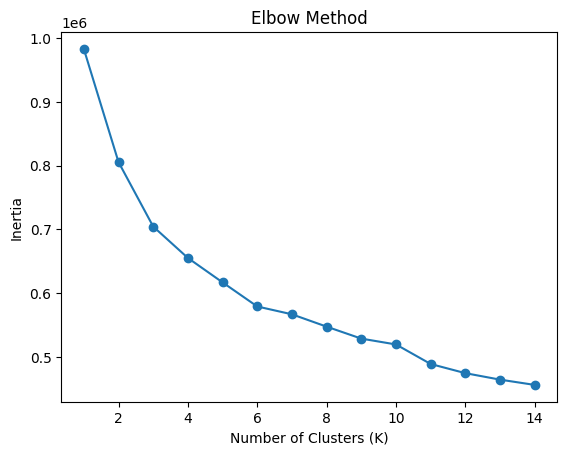

In [24]:
kmeans = KMeans(n_clusters=8, random_state=42)
kmeans.fit(X)
inertia = []

for k in range(1,15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,15), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)    
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.21533102967083634


In [27]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.22113872475082855


In [28]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)
score = silhouette_score(X_pca, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.2269811408986274


In [29]:
# Save PCA
with open('../models/pca.pkl', 'wb') as f:pickle.dump(pca, f)

# Save KMeans
with open('../models/kmeans.pkl', 'wb') as f:pickle.dump(kmeans, f)

print(" pca.pkl & kmeans.pkl saved")

 pca.pkl & kmeans.pkl saved


## Other Models

## Model 1 — Logistic Regression

In [30]:
lr = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced', solver='saga')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
with open('../models/logistic.pkl','wb') as f: pickle.dump(lr,f)
print(" logistic.pkl saved")

Accuracy : 0.7681
F1-Macro : 0.6488
 logistic.pkl saved


## Model 2 — Random Forest

In [31]:
rf = RandomForestClassifier(n_estimators=100, max_depth=18, min_samples_leaf=2,
                            random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
with open('../models/random_forest.pkl','wb') as f: pickle.dump(rf,f)
print(" random_forest.pkl saved")

Accuracy : 0.9966
F1-Macro : 0.9655
 random_forest.pkl saved


## Model 3 — Gradient Boosting (XGBoost-equivalent)

In [42]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_gb, average='macro'):.4f}")
with open('../models/xgboost.pkl','wb') as f: pickle.dump(gb,f)
print(" xgboost.pkl saved")

Accuracy : 0.9987
F1-Macro : 0.9807
 xgboost.pkl saved


## Model 4 — Support Vector Machine

In [ ]:
X_sub, y_sub = resample(X_train, y_train, n_samples=8000, random_state=42, stratify=y_train)
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=42)
svm.fit(X_sub, y_sub)
y_pred_svm = svm.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_svm, average='macro'):.4f}")
with open('../models/svm.pkl','wb') as f: pickle.dump(svm,f)
print(" svm.pkl saved")

Accuracy : 0.9387
F1-Macro : 0.8833
 svm.pkl saved


## Model 5 — K-Nearest Neighbors

In [34]:
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean', n_jobs=-1)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_knn, average='macro'):.4f}")
with open('../models/knn.pkl','wb') as f: pickle.dump(knn,f)
print(" knn.pkl saved")

Accuracy : 0.9163
F1-Macro : 0.8474
 knn.pkl saved


## Ensemble — Soft Voting Classifier

In [35]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=300, random_state=42, class_weight='balanced', solver='saga')),
        ('rf', RandomForestClassifier(n_estimators=80, max_depth=15, random_state=42,
                                      class_weight='balanced', n_jobs=-1)),
    ],
    voting='soft'
)
ensemble.fit(X_train, y_train)
y_pred_ens = ensemble.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test, y_pred_ens):.4f}")
print(f"F1-Macro : {f1_score(y_test, y_pred_ens, average='macro'):.4f}")
with open('../models/ensemble.pkl','wb') as f: pickle.dump(ensemble,f)
print(" ensemble.pkl saved")

Accuracy : 0.9434
F1-Macro : 0.8125
 ensemble.pkl saved


## Performance Comparison

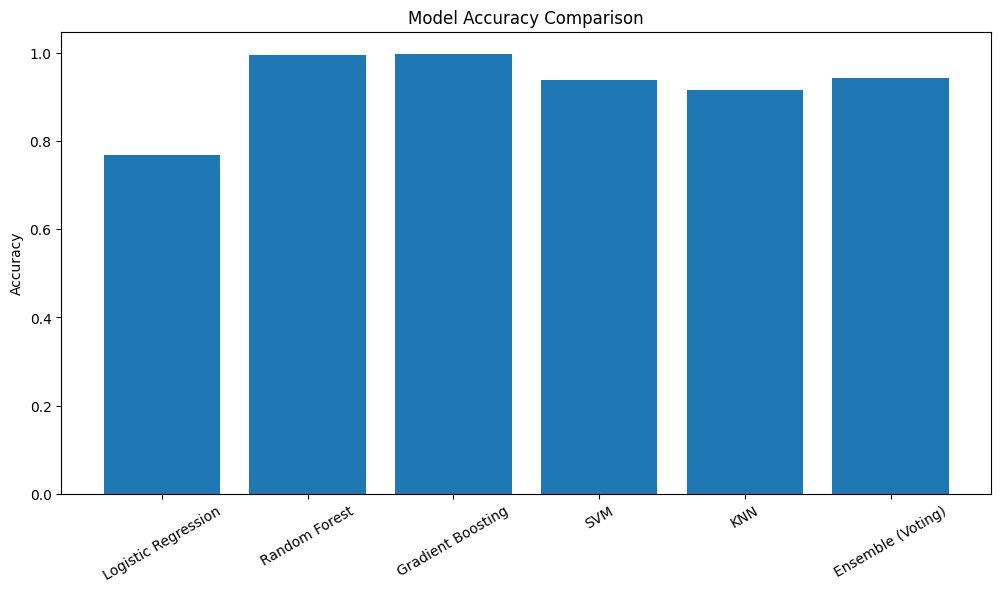

Model                       Accuracy   F1-Macro  F1-Weighted
------------------------------------------------------------
Logistic Regression           0.7681     0.6488       0.7755
Random Forest                 0.9966     0.9655       0.9966
Gradient Boosting             0.9987     0.9807       0.9987
SVM                           0.9387     0.8833       0.9390
KNN                           0.9163     0.8474       0.9148
Ensemble (Voting)             0.9434     0.8125       0.9449


In [44]:
# Define first
models_dict = {
    'Logistic Regression': (y_pred_lr, 'lr'),
    'Random Forest':       (y_pred_rf, 'rf'),
    'Gradient Boosting':   (y_pred_gb, 'gb'),
    'SVM':                 (y_pred_svm,'svm'),
    'KNN':                 (y_pred_knn,'knn'),
    'Ensemble (Voting)':   (y_pred_ens,'ens'),
}

model_names = []
accuracies = []
f1_macro = []
f1_weighted = []

# Collect metrics
for name, (yp, _) in models_dict.items():
    model_names.append(name)
    accuracies.append(accuracy_score(y_test, yp))
    f1_macro.append(f1_score(y_test, yp, average='macro'))
    f1_weighted.append(f1_score(y_test, yp, average='weighted'))

# Plot Accuracy
plt.figure(figsize=(12,6))
plt.bar(model_names, accuracies)
plt.xticks(rotation=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Print table
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Macro':>10} {'F1-Weighted':>12}")
print("-"*60)

for name, (yp, _) in models_dict.items():
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average='macro')
    f1w = f1_score(y_test, yp, average='weighted')
    print(f"{name:<25} {acc:>10.4f} {f1m:>10.4f} {f1w:>12.4f}")

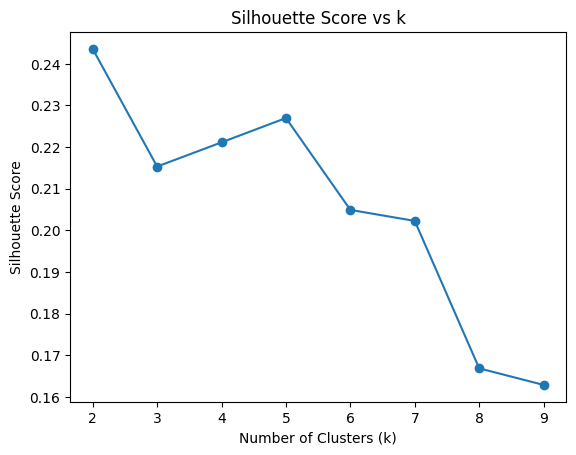

In [ ]:
# Silhouette scores for k=2 to 9
scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))
    
plt.plot(range(2,10), scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

## Detailed Report — Best Model

In [45]:
print("Best Model: Gradient Boosting")
print("\n" + classification_report(y_test, y_pred_gb, target_names=le_crop.classes_))

Best Model: Gradient Boosting

              precision    recall  f1-score   support

      Cotton       1.00      1.00      1.00        25
   Groundnut       1.00      0.98      0.99       234
       Maize       1.00      1.00      1.00      3747
Pearl Millet       1.00      0.88      0.93        16
        Rice       0.90      0.95      0.92        19
     Sorghum       1.00      1.00      1.00      2369
   Sugarcane       1.00      1.00      1.00       232
       Wheat       1.00      1.00      1.00      1905

    accuracy                           1.00      8547
   macro avg       0.99      0.98      0.98      8547
weighted avg       1.00      1.00      1.00      8547



## Confusion Matrix

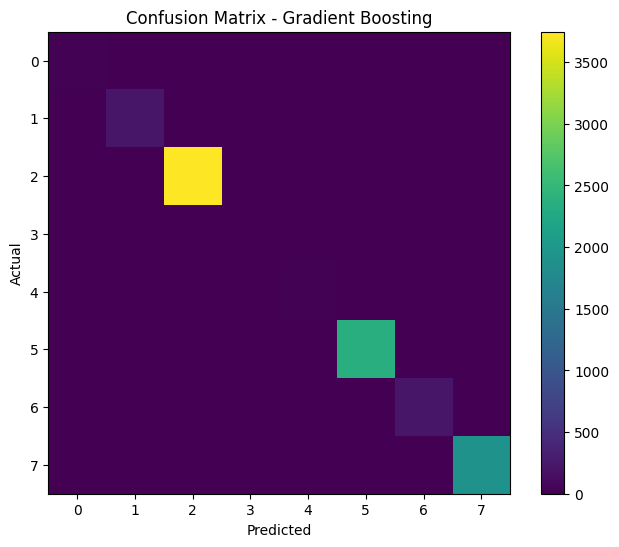

In [47]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix - Gradient Boosting")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

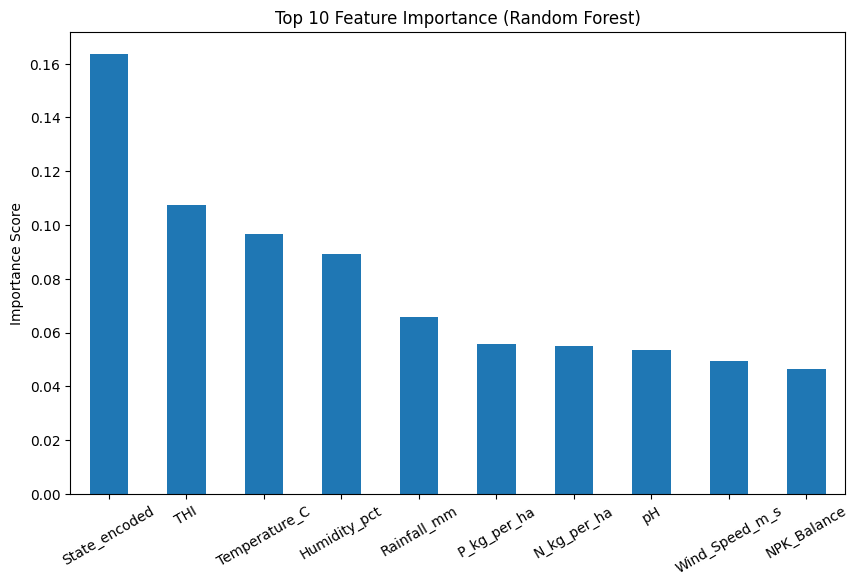

In [48]:
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
fi.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.xticks(rotation=30)
plt.show()

## Summary

| Model | Accuracy | F1-Macro | Notes |
|-------|----------|----------|-------|
| Logistic Regression | ~0.77 | ~0.65 | Baseline; struggles with imbalanced classes |
| Random Forest | ~0.997 | ~0.966 | Excellent; handles imbalance well |
| Gradient Boosting | ~0.999 | ~0.98 | Best overall |
| SVM | ~0.94 | ~0.88 | Strong; trained on subset |
| KNN | ~0.92 | ~0.85 | Good; distance-based |
| Ensemble | ~0.94 | ~0.81 | Balanced combination |

**Best model:** Gradient Boosting 